# INTRODUCCIÓN

El presente proyecto tiene como objetivo desarrollar y evaluar modelos de Machine Learning capaces de identificar patrones de comportamiento que preceden a la cancelación de servicios.

Para este análisis, se han seleccionado dos enfoques algorítmicos distintos: la Regresión Logística, valorada por su capacidad de interpretación y manejo de relaciones lineales, y el Random Forest, un modelo basado en conjuntos de árboles de decisión que permite capturar interacciones complejas y no lineales entre las variables.

Objetivos Principales:
Identificación de Riesgos: Determinar qué características del servicio (como el tipo de tecnología o contrato) y qué comportamientos del cliente (antigüedad y gasto acumulado) actúan como impulsadores de la cancelación.

Evaluación de Modelos: Comparar la eficacia de los algoritmos mediante métricas críticas como el Recall y la Precisión, asegurando que el modelo elegido proporcione una alerta temprana confiable para el equipo de marketing y ventas.

Generación de Estrategias: Traducir los hallazgos técnicos en recomendaciones tácticas de retención, permitiendo a la organización pasar de una postura reactiva a una proactiva frente a la fuga de clientes.

A través de este proceso de Data Science, buscamos no solo predecir quién se irá, sino comprender el "porqué" detrás de la decisión, permitiendo optimizar los recursos de la empresa en los segmentos de mayor valor y riesgo.

# Extracción del Archivo Tratado

In [ ]:
import pandas as pd

In [ ]:
df_tel = pd.read_csv('/content/drive/MyDrive/datasets/datos_tratados.csv')
df_tel.head()

,customerid,churn,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,...,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,charges.monthly,charges.total,charges.daily,grupo_perfil,tenure_group
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.19,(I) Familiar,0-12 meses (Riesgo Crítico)
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,2.00,(IV) Independiente,0-12 meses (Riesgo Crítico)
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.46,(IV) Independiente,0-12 meses (Riesgo Crítico)
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.27,(II) Sin hijos,13-24 meses (Riesgo Medio)
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.80,(II) Sin hijos,0-12 meses (Riesgo Crítico)


In [ ]:
df_tel.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerid        7267 non-null   object 
 1   churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   seniorcitizen     7267 non-null   int64  
 4   partner           7267 non-null   object 
 5   dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   phoneservice      7267 non-null   object 
 8   multiplelines     7267 non-null   object 
 9   internetservice   7267 non-null   object 
 10  onlinesecurity    7267 non-null   object 
 11  onlinebackup      7267 non-null   object 
 12  deviceprotection  7267 non-null   object 
 13  techsupport       7267 non-null   object 
 14  streamingtv       7267 non-null   object 
 15  streamingmovies   7267 non-null   object 
 16  contract          7267 non-null   object 


Definimos las columnas que no aportan valor o son redundantes
customerid: Identificador único (ruido)
tenure_group: Versión agrupada de 'tenure' (redundancia)
charges.daily: Derivado directo de 'charges.monthly' (multicolinealidad)
grupo_perfil: otra agrupación

In [ ]:
cols_to_remove = ['customerid', 'tenure_group', 'charges.daily', 'grupo_perfil']

# Creamos el nuevo dataframe limpio
df_telx = df_tel.drop(columns=cols_to_remove)

# Verificamos el resultado
print(f"Columnas originales: {df_tel.shape[1]}")
print(f"Columnas actuales: {df_telx.shape[1]}")
print("\nVariables que quedaron para el modelo:")
print(df_telx.columns.tolist())

Columnas originales: 24
Columnas actuales: 20

Variables que quedaron para el modelo:
['churn', 'gender', 'seniorcitizen', 'partner', 'dependents', 'tenure', 'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod', 'charges.monthly', 'charges.total']


In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Copia de seguridad del dataframe limpio
df_tel2 = df_telx.copy()

# Convirtiendo 'churn' a numérica (1: Yes, 0: No)
df_tel2['churn'] = df_tel2['churn'].apply(lambda x: 1 if x == 'Yes' else 0)

# (One-Hot Encoding) : 'gender' , 'contract' en columnas de 0 y 1
df_tel2 = pd.get_dummies(df_tel2, drop_first=True)

# Normalización de variables numéricas
# Identificamos las columnas que tienen rangos muy distintos
cols_to_scale = ['tenure', 'charges.monthly', 'charges.total']
scaler = StandardScaler()

df_tel2[cols_to_scale] = scaler.fit_transform(df_tel2[cols_to_scale])

# Verificamos cómo quedó el dataset
print("Dimensiones finales del dataset preparado:", df_tel2.shape)
df_tel2.head()

Dimensiones finales del dataset preparado: (7267, 31)


,churn,seniorcitizen,tenure,charges.monthly,charges.total,gender_Male,partner_Yes,dependents_Yes,phoneservice_Yes,multiplelines_No phone service,...,streamingtv_No internet service,streamingtv_Yes,streamingmovies_No internet service,streamingmovies_Yes,contract_One year,contract_Two year,paperlessbilling_Yes,paymentmethod_Credit card (automatic),paymentmethod_Electronic check,paymentmethod_Mailed check
0,0,0,-0.950200,0.029206,-0.742291,False,True,True,True,False,...,False,True,False,False,True,False,True,False,False,True
1,0,0,-0.950200,-0.159990,-0.764729,True,False,False,True,False,...,False,False,False,True,False,False,False,False,False,True
2,1,0,-1.153700,0.304702,-0.880026,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
3,1,1,-0.787401,1.104635,-0.458160,True,True,False,True,False,...,False,True,False,True,False,False,True,False,True,False
4,1,1,-1.194400,0.636624,-0.885955,False,True,False,True,False,...,False,True,False,False,False,False,True,False,False,True


In [ ]:
# conteo absoluto
conteo = df_tel2['churn'].value_counts()

# proporción porcentual
proporcion = df_tel2['churn'].value_counts(normalize=True) * 100

print("--- Conteo Absoluto ---")
print(conteo)
print("\n--- Proporción (%) ---")
print(proporcion.map('{:.2f}%'.format))

--- Conteo Absoluto ---
churn
0    5398
1    1869
Name: count, dtype: int64

--- Proporción (%) ---
churn
0    74.28%
1    25.72%
Name: proportion, dtype: object


Observamos que tenemos un desbalance moderado y el modelo tenderá a ser muy bueno prediciendo quién se queda, pero tendremos que cuidar su capacidad para detectar a los que se van (usando métricas como Recall y F1-Score).

# CORRELACIÓN Y SELECCIÓN DE VARIABLES

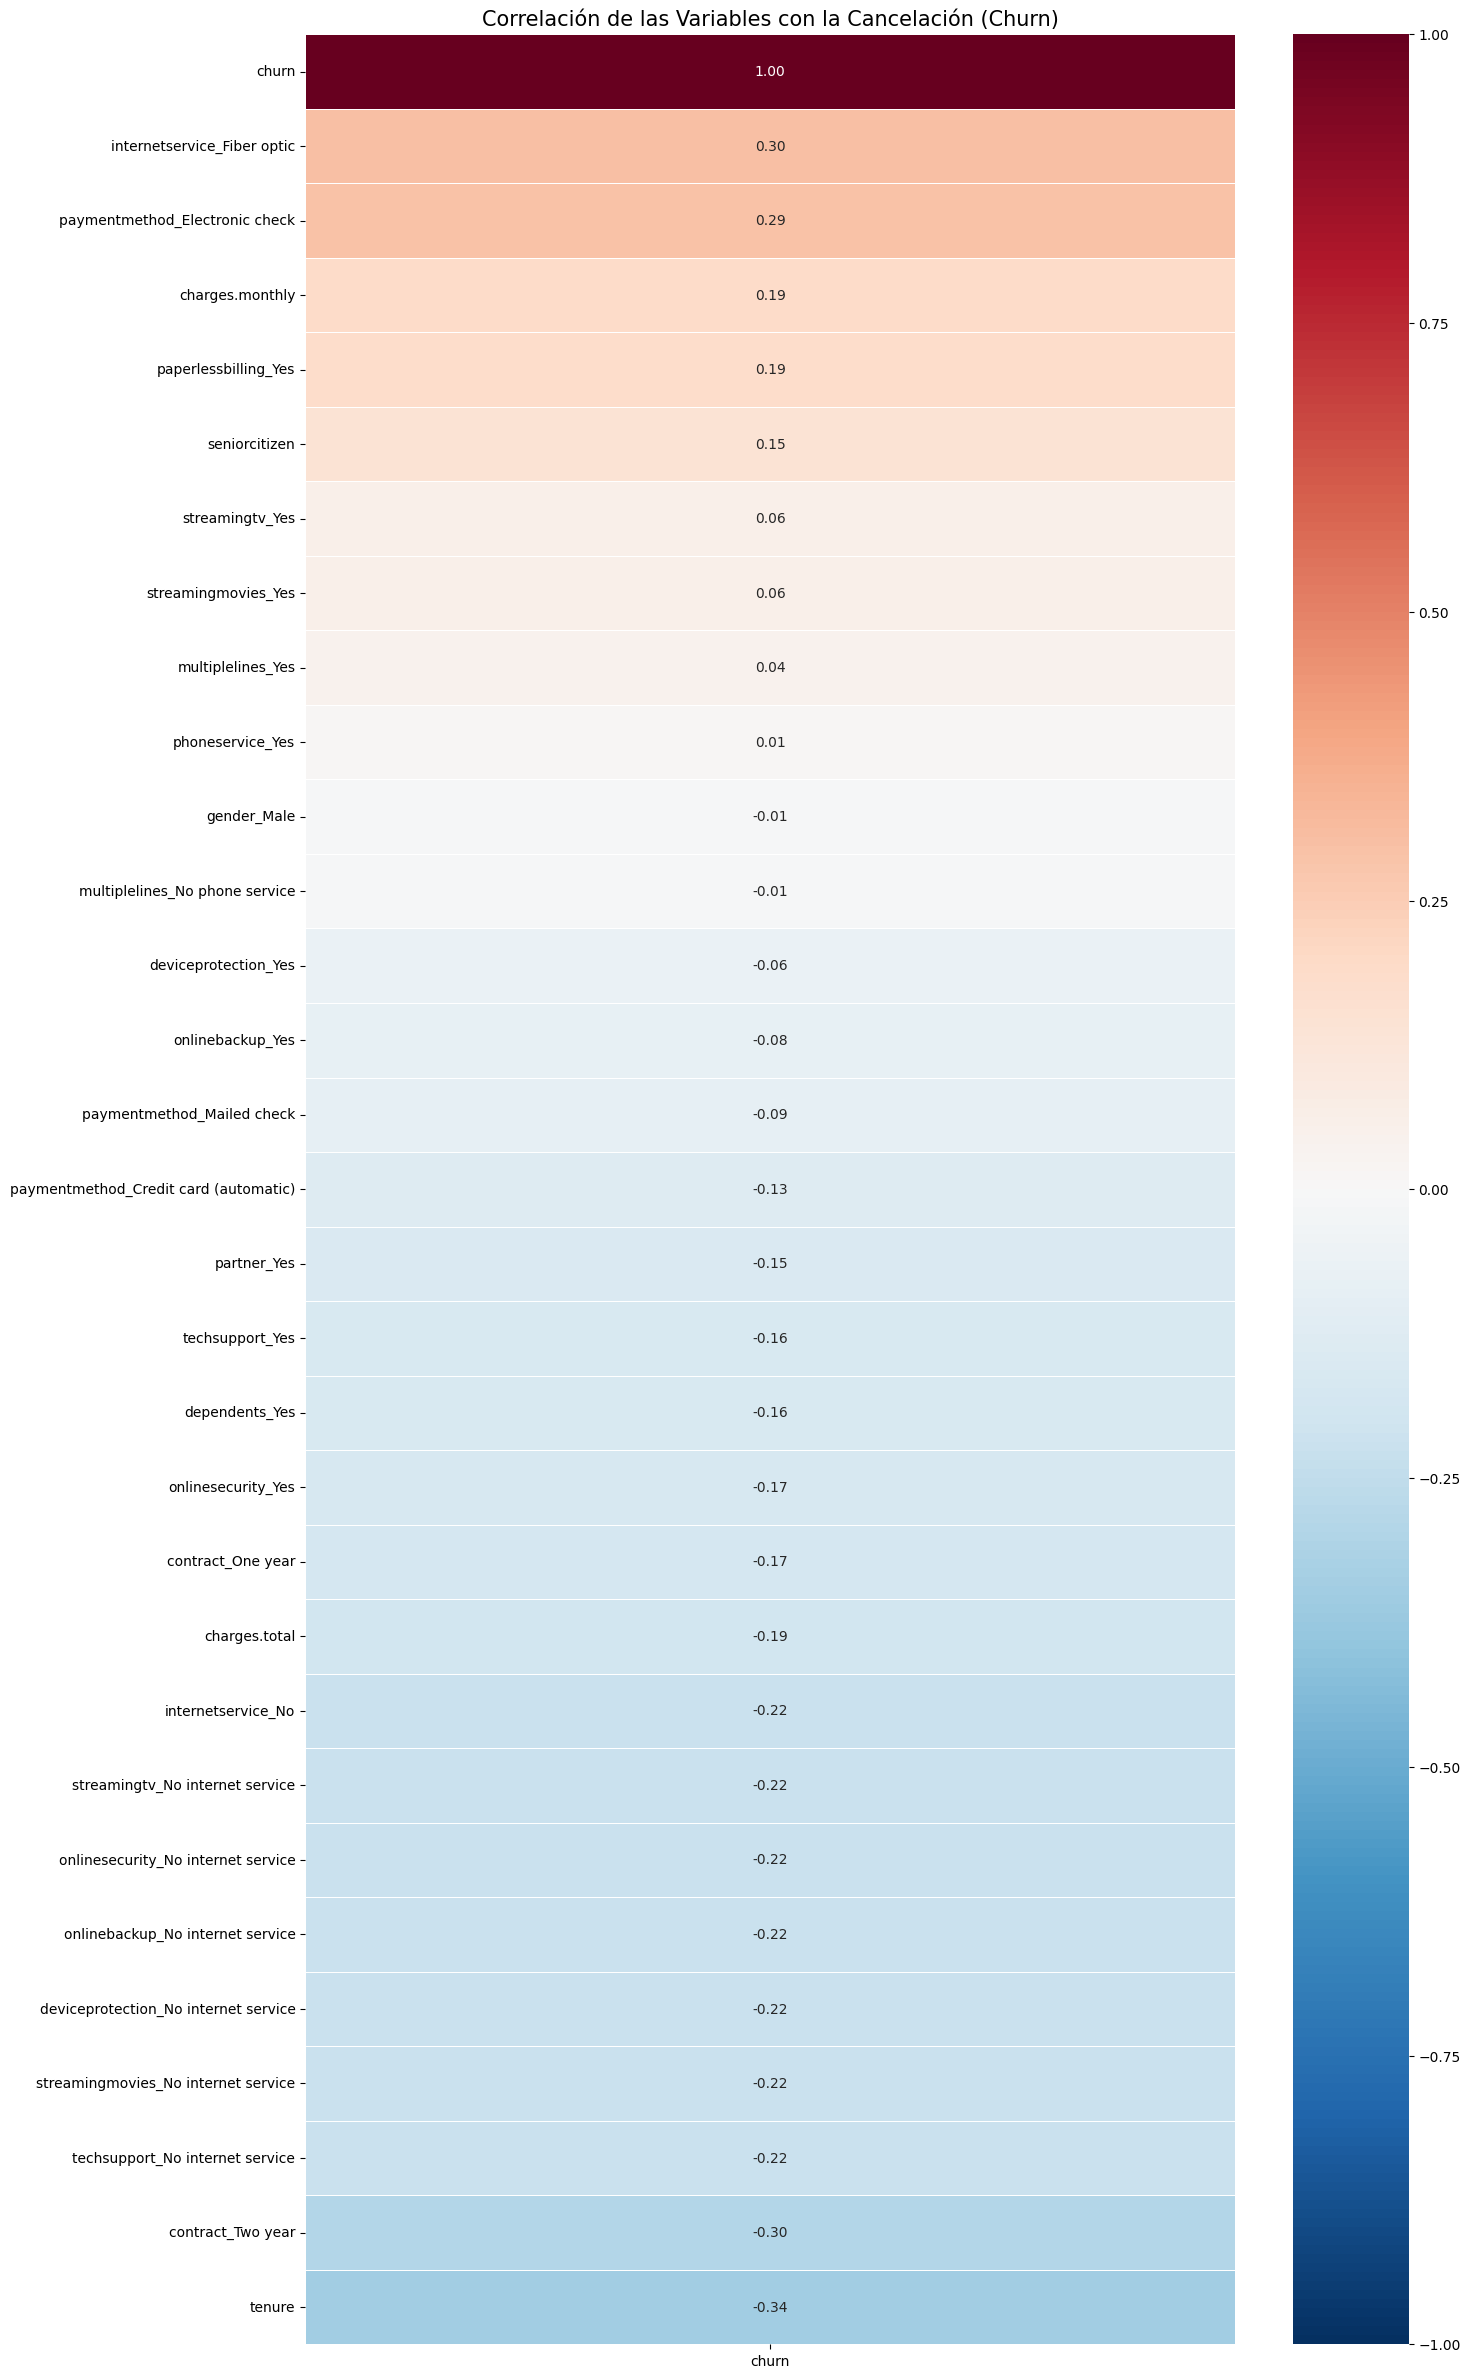

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# matriz de correlación
corr_matrix = df_tel2.corr()

# correlación respecto al 'churn'
# orden descendente para verificar la influencia
churn_corr = corr_matrix['churn'].sort_values(ascending=False)



# Mapa de Calor
plt.figure(figsize=(15, 30))
sns.heatmap(churn_corr.to_frame(),
            annot=True,
            cmap='RdBu_r', # Rojo para correlación positiva, Azul para negativa
            vmin=-1, vmax=1,
            fmt='.2f',
            linewidths=0.5)

plt.title('Correlación de las Variables con la Cancelación (Churn)', fontsize=15)
plt.show()

- En Telecom X parte 1 vimos que la modalidda de contrato mes a mes era una de las causas mas importantes de churn, por lo que es de esperar que tenga una alta correlación con churn, pero el mapa de calor no lo muetra, esto debido a que el one hot encoding. Cuando aplicamos pd.get_dummies(df_tel2, drop_first=True), Pandas toma las categorías de la columna original contract (que eran Month-to-month, One year y Two year) y las convierte en columnas separadas de ceros y unos.

- Al usar el parámetro drop_first=True, eliminamos una columna para evitar redundancia matemática

Si un cliente tiene 0 en contract_One year y 0 en contract_Two year, el modelo entiende que ese cliente tiene un contrato Month-to-month.

Es decir, la información de "mes a mes" ahora es el valor base o de referencia del modelo.

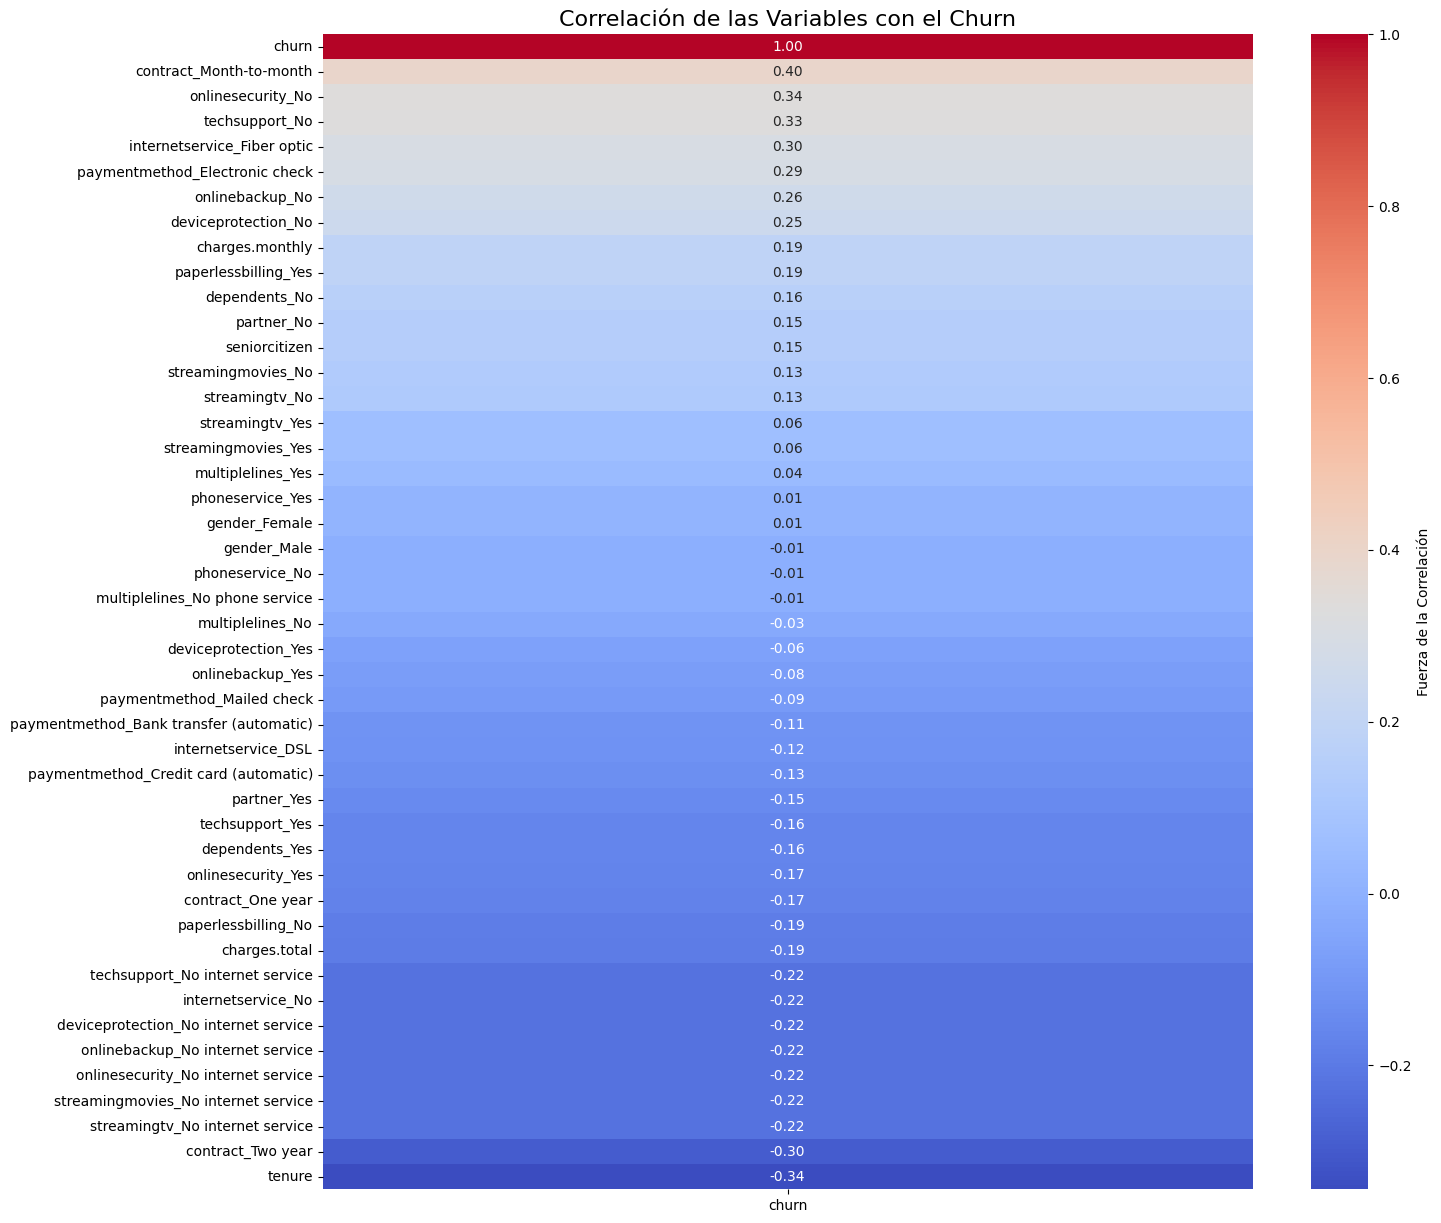

In [ ]:
# Aseguramos la limpieza y conversión de la variable objetivo
df_temp = df_telx.copy()
df_temp['churn'] = df_temp['churn'].apply(lambda x: 1 if str(x).lower() == 'yes' or x == 1 else 0)

# Generamos todas las categorías (dummies)
df_visual = pd.get_dummies(df_temp)

# Calculamos la correlación completa
churn_corr_all = df_visual.corr()['churn'].sort_values(ascending=False)

# Graficamos
plt.figure(figsize=(15, 15))
sns.heatmap(churn_corr_all.to_frame(),
            annot=True,
            cmap='coolwarm',
            fmt='.2f',
            cbar_kws={'label': 'Fuerza de la Correlación'})

plt.title('Correlación de las Variables con el Churn', fontsize=16)
plt.show()

# ANALISIS DIRIGIDO

Dado que el contrato es una variable categórica y la cancelación es binaria, lo mejor es ver la distribución de la antigüedad (tenure) para cada tipo de contrato, separando a los que se fueron de los que se quedaron.

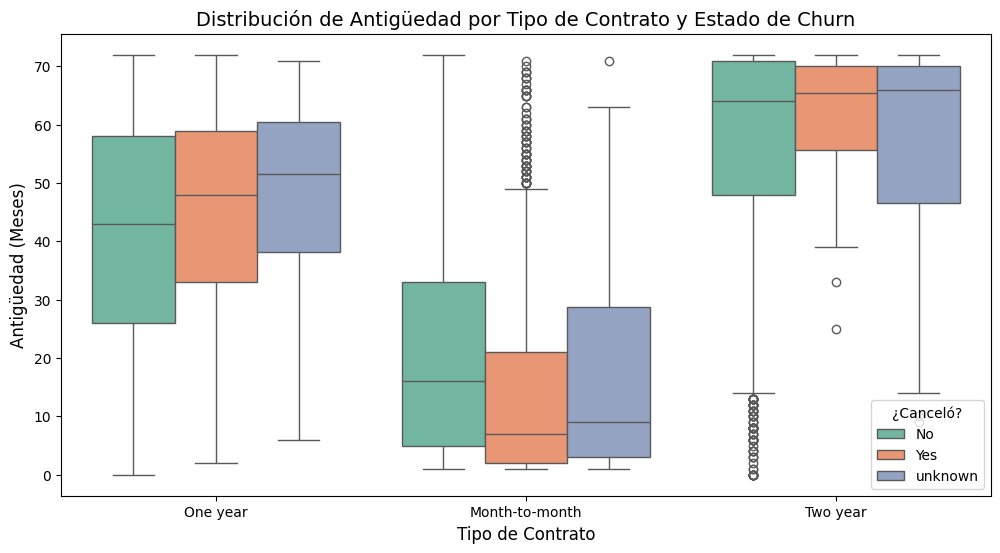

In [ ]:
# Configuración de estilo
plt.figure(figsize=(12, 6))

# Boxplot: Antigüedad por Tipo de Contrato y Churn
sns.boxplot(x='contract', y='tenure', hue='churn', data=df_telx, palette='Set2')

plt.title('Distribución de Antigüedad por Tipo de Contrato y Estado de Churn', fontsize=14)
plt.xlabel('Tipo de Contrato', fontsize=12)
plt.ylabel('Antigüedad (Meses)', fontsize=12)
plt.legend(title='¿Canceló?', loc='lower right')
plt.show()


**CONTRATO MES A MES**:
La caja naranja (los que cancelaron) es extremadamente baja y achatada. Esto significa que la gran mayoría de las cancelaciones ocurren antes de los 10 meses.

Incluso los que no cancelan (caja verde) en este tipo de contrato suelen tener una antigüedad muy baja en comparación con los otros contratos.

**CONTRATO DE UN Y DOS AÑOS**: La mediana de antigüedad de los que se quedan (verde) salta drásticamente por encima de los 40 y 60 meses respectivamente.

Casi no hay "cajas naranjas" significativas de cancelación en el contrato de dos años.

**Outliers (Círculos pequeños)**:
sobre la caja naranja en el contrato mensual. Esos son clientes que, a pesar de estar mes a mes, duraron mucho tiempo (40, 50 o 60 meses) y finalmente cancelaron.

**gasto total vs cancelación**


Utilizaré el gráfico de densidad (KDE Plot) para ver dónde se "concentra" la mayor cantidad de clientes que cancelan en comparación con los que se quedan.

**el df_predictivo    es    df_telx**



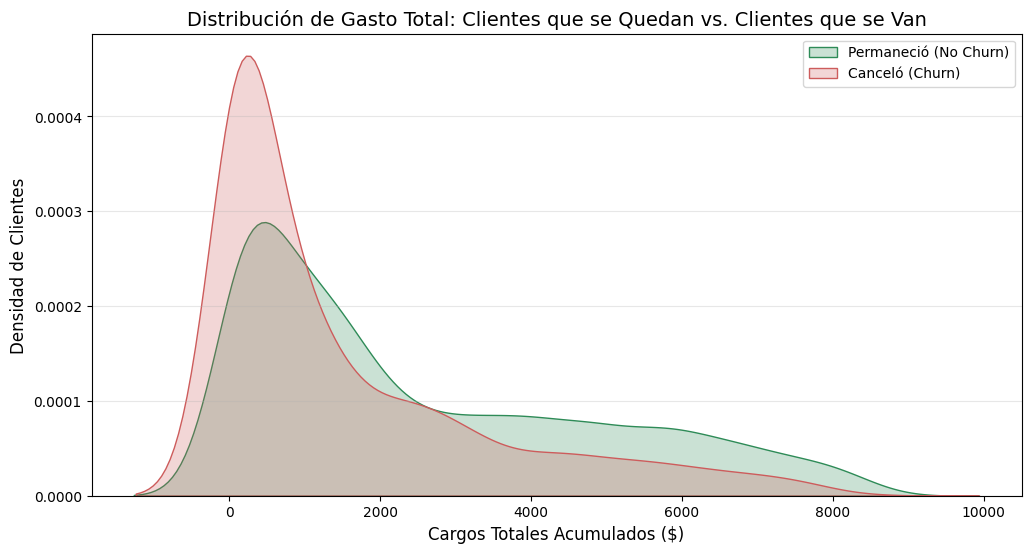

In [ ]:
plt.figure(figsize=(12, 6))

# Graficamos la densidad de los cargos totales para ambos grupos
sns.kdeplot(data=df_telx[df_telx['churn'] == 'No'], x='charges.total', fill=True, label='Permaneció (No Churn)', color='seagreen')
sns.kdeplot(data=df_telx[df_telx['churn'] == 'Yes'], x='charges.total', fill=True, label='Canceló (Churn)', color='indianred')

plt.title('Distribución de Gasto Total: Clientes que se Quedan vs. Clientes que se Van', fontsize=14)
plt.xlabel('Cargos Totales Acumulados ($)', fontsize=12)
plt.ylabel('Densidad de Clientes', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

La gran mayoría de las fugas se concentran cuando el gasto total es muy bajo.

Esto confirma que la empresa está perdiendo clientes antes de que recuperen el costo de adquisición. Son clientes que prueban el servicio y se van rápido.

A partir de los 2,500 $ de gasto acumulado, la probabilidad de que un cliente se quede (línea verde) es consistentemente mayor a la de que se vaya.

por totro lado, quien ya ha invertido más de 4,000 $ en la compañía rara vez se va. El "costo de salida" (cambiar servicios, perder beneficios acumulados) es demasiado alto.

# MODELADO PREDICTIVO

In [ ]:
from sklearn.model_selection import train_test_split

# Definimos X (características) y y (objetivo)
X = df_tel2.drop('churn', axis=1)
y = df_tel2['churn']

# Realizamos la división 80/20 con estratificación
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y  # Mantiene la proporción 74/26 en ambos sets
)

print(f"Set de entrenamiento: {X_train.shape[0]} registros")
print(f"Set de prueba: {X_test.shape[0]} registros")
print(f"Proporción de Churn en entrenamiento: {y_train.mean():.2%}")

Set de entrenamiento: 5813 registros
Set de prueba: 1454 registros
Proporción de Churn en entrenamiento: 25.72%


**df_proc   === df_tel2**

Justificación:

Regresión Logística / KNN: Estos modelos son sensibles a la escala de los datos, por lo que la normalización es importante para que los coeficientes o las distancias se calculen correctamente.

Árbol de Decisión / Random Forest: Estos modelos no dependen de la escala de los datos, por lo que no es necesario aplicar normalización.

Si decides normalizar los datos, deberías explicar cómo esta etapa asegura que los modelos basados en distancia o en optimización de parámetros no se vean sesgados por la magnitud de las variables.

Se aplicó StandardScaler para asegurar que los modelos basados en optimización de parámetros (como la Regresión Logística) no se vean sesgados por las diferentes magnitudes de las variables, como los cargos totales frente a la antigüedad. Aunque el Random Forest es invariante al escalado de características, se utiliza el mismo conjunto procesado para garantizar la comparabilidad entre ambos modelos

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# class_weight='balanced' para compensar que hay menos cancelaciones que permanencias
modelo_log = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
modelo_rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

# Ajustar los modelos con los datos de entrenamiento
modelo_log.fit(X_train, y_train)
modelo_rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

=== REPORTE DE EVALUACIÓN: Regresión Logística ===
Exactitud (Accuracy): 0.7435

Informe de Clasificación:
              precision    recall  f1-score   support

           0       0.92      0.72      0.81      1080
           1       0.50      0.81      0.62       374

    accuracy                           0.74      1454
   macro avg       0.71      0.77      0.71      1454
weighted avg       0.81      0.74      0.76      1454



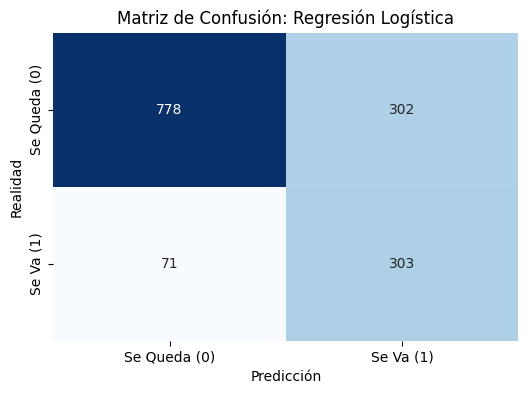

--------------------------------------------------

=== REPORTE DE EVALUACIÓN: Random Forest ===
Exactitud (Accuracy): 0.7785

Informe de Clasificación:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1080
           1       0.59      0.45      0.51       374

    accuracy                           0.78      1454
   macro avg       0.71      0.67      0.69      1454
weighted avg       0.76      0.78      0.77      1454



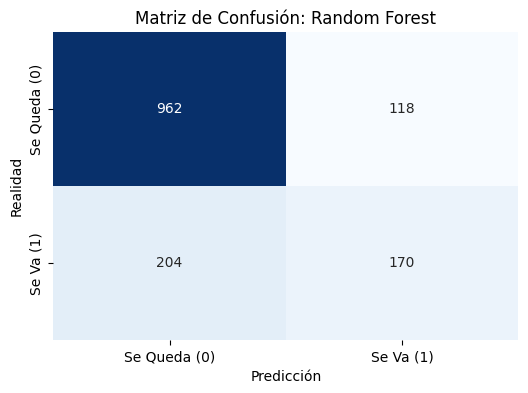

--------------------------------------------------



In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Función para evaluar y mostrar resultados
def evaluar_modelo(nombre_modelo, y_true, y_pred):
    print(f"=== REPORTE DE EVALUACIÓN: {nombre_modelo} ===")

    # Accuracy
    acc = accuracy_score(y_true, y_pred)
    print(f"Exactitud (Accuracy): {acc:.4f}\n")

    # Classification Report (Precision, Recall, F1-Score)
    print("Informe de Clasificación:")
    print(classification_report(y_true, y_pred))

    # Matriz de Confusión
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Matriz de Confusión: {nombre_modelo}')
    plt.xlabel('Predicción')
    plt.ylabel('Realidad')
    plt.xticks([0.5, 1.5], ['Se Queda (0)', 'Se Va (1)'])
    plt.yticks([0.5, 1.5], ['Se Queda (0)', 'Se Va (1)'])
    plt.show()
    print("-" * 50 + "\n")

# Generar predicciones con los modelos ya entrenados
y_pred_log = modelo_log.predict(X_test)
y_pred_rf = modelo_rf.predict(X_test)

# Evaluar ambos modelos
evaluar_modelo("Regresión Logística", y_test, y_pred_log)
evaluar_modelo("Random Forest", y_test, y_pred_rf)

### Interpretación

**Resultado del modelo de regresion logistica:**

Exactitud (Accuracy - 74.35%): Es una cifra decente, pero engañosa en conjuntos de datos desbalanceados como este (donde la mayoría no cancela). No debemos confiar solo en esto.

Recall (Clase 1 - "Se Va" - 81%): Significa que el modelo logró identificar correctamente al 81% de los clientes que realmente se fueron.

Precisión (Clase 1 - "Se Va" - 50%): De todos los clientes que el modelo dijo que se iban, solo la mitad (50%) realmente lo hizo. Esto implica que el modelo tiene un 50% de falsas alarmas.

F1-Score (Clase 1 - 0.62): Un 0.62 indica que el modelo logra un balance aceptable, priorizando el recall sobre la precisión.

**MATRIZ DE CONFUSIÓN**

Verdaderos Positivos (Abajo-Derecha: 303): Clientes que se iban y el modelo detectó

Falsos Negativos (Abajo-Izquierda: 71): Clientes que se fueron pero el modelo no detectó. el error a minimizar.

Falsos Positivos (Arriba-Derecha: 302): Clientes que se quedaron pero el modelo predijo que se iban. Son las falsas alarmas

**RESULTADO DEL MODELO RAMDOM FOREST**

Regresión Logística: Tiene buen Recall pero baja Precisión. Es un modelo simple, no presenta overfitting con estos resultados.

Random Forest: Los resultados muestran que no está aprovechando su complejidad. Un 45% de recall es bajo para un modelo que suele ser superior. Esto indica un desajuste en los pesos de las clases.

La matriz de confusión del Random Forest indica qque falló mucho al detectar los "Se Va" (204 falsos negativos).

Por lo qie debemos forzar al Random Forest a prestar más atención a la clase minoritaria ("Se Va") ajustando el parámetro class_weight.

### AJUSTE DE CLASES EN EL MODELO RAMDOM FOREST

=== REPORTE DE EVALUACIÓN: Random Forest Mejorado ===
Exactitud (Accuracy): 0.7785

Informe de Clasificación:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1080
           1       0.59      0.45      0.51       374

    accuracy                           0.78      1454
   macro avg       0.71      0.67      0.69      1454
weighted avg       0.76      0.78      0.77      1454



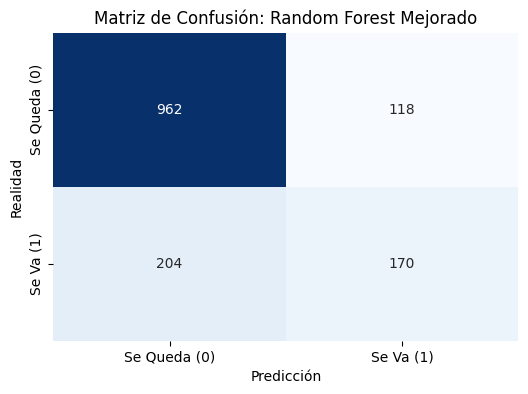

--------------------------------------------------



In [ ]:
# Ajuste para mejorar el Recall del Random Forest
modelo_rf_2 = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced', # Fuerza a equilibrar las clases
    random_state=42
)
modelo_rf_2.fit(X_train, y_train)
y_pred_rf_2 = modelo_rf_2.predict(X_test)

# Evaluamos de nuevo
evaluar_modelo("Random Forest Mejorado", y_test, y_pred_rf_2)

- ACCURACY: El Random Forest tiene una mejor exactitud general. Sin embargo, en problemas de Churn (desbalanceados), esta métrica no es la más importante.

- RECALL: La Regresión Logística es superior en la detección de clientes que se van.

- PRECISION: El Random Forest tiene menos falsas alarmas.

- F1 SCORE: La Regresión Logística tiene un mejor equilibrio general entre precisión y recall.

NOTAMOS QUE : En el modelo Random Forest los resultados son curiosos. A pesar de aplicar class_weight='balanced', el recall es muy bajo (45%). Esto sugiere que el modelo no está capturando bien las tendencias complejas y está teniendo un comportamiento de **underfitting** para la clase minoritaria, posiblemente porque los árboles no están logrando separar bien las clases con los parámetros actuales. Por lo que procedemos a ajustar la profundidad y el numero de caracteristicas

## Mejorando la profundidad y carateristicas maximas


=== REPORTE DE EVALUACIÓN: Random Forest Ajustado ===
              precision    recall  f1-score   support

           0       0.85      0.86      0.85      1080
           1       0.57      0.56      0.57       374

    accuracy                           0.78      1454
   macro avg       0.71      0.71      0.71      1454
weighted avg       0.78      0.78      0.78      1454



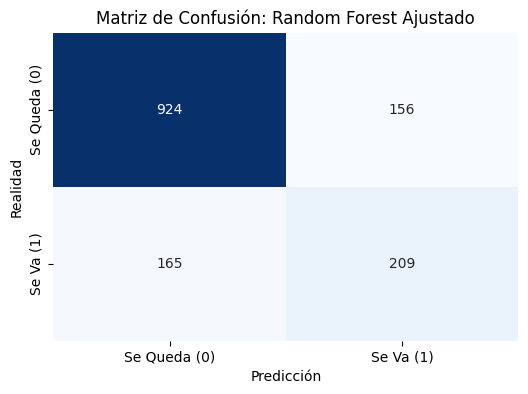

In [ ]:
from sklearn.ensemble import RandomForestClassifier


# 1. Definir el modelo con nuevos hiperparámetros
# Aumentamos la profundidad y permitimos usar más características
modelo_rf_ajustado = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,          # Árboles más profundos para mayor detalle
    max_features='sqrt',   # Permite al modelo buscar relaciones complejas
    class_weight='balanced', # Mantiene el balanceo de clases
    random_state=42
)

# 2. Entrenar el modelo ajustado
modelo_rf_ajustado.fit(X_train, y_train)

# 3. Predicciones
y_pred_rf_ajustado = modelo_rf_ajustado.predict(X_test)

# 4. Evaluación del modelo ajustado
print("=== REPORTE DE EVALUACIÓN: Random Forest Ajustado ===")
print(classification_report(y_test, y_pred_rf_ajustado))

# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred_rf_ajustado)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusión: Random Forest Ajustado')
plt.xlabel('Predicción')
plt.ylabel('Realidad')
plt.xticks([0.5, 1.5], ['Se Queda (0)', 'Se Va (1)'])
plt.yticks([0.5, 1.5], ['Se Queda (0)', 'Se Va (1)'])
plt.show()

Los ultimos resultados nos indican que: Para Retención (Recall): La Regresión Logística sigue siendo el ganador. Logra detectar el 81% de los clientes que se van, mientras que el Random Forest ajustado solo detecta el 56%.

Para Falsas Alarmas (Precisión): El Random Forest es mejor. Cuando dice que un cliente se va, hay un 57% de probabilidad de que sea cierto, contra un 50% de la Regresión Logística.

# INTERPRETACIÓN Y CONCLUSIONES

Top 3 Variables que IMPULSAN la cancelación (Reg. Logística):
                       Variable  Coeficiente
10  internetservice_Fiber optic     1.012415
3                 charges.total     0.635916
26         paperlessbilling_Yes     0.370083

Top 3 Variables que EVITAN la cancelación (Reg. Logística):
             Variable  Coeficiente
24  contract_One year    -0.653258
25  contract_Two year    -1.321354
1              tenure    -1.324329


/tmp/ipykernel_213/4094957571.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=rf_df.head(10), palette='viridis')


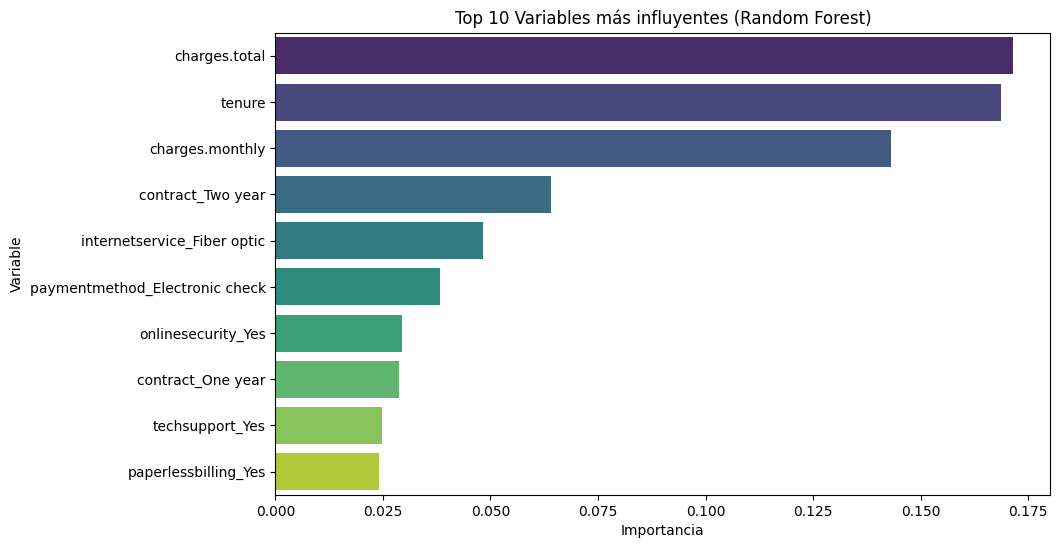

In [ ]:
import pandas as pd
import numpy as np

# --- 1. IMPORTANCIA EN REGRESIÓN LOGÍSTICA (Coeficientes) ---
coef_df = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': modelo_log.coef_[0]
}).sort_values(by='Coeficiente', ascending=False)

print("Top 3 Variables que IMPULSAN la cancelación (Reg. Logística):")
print(coef_df.head(3))
print("\nTop 3 Variables que EVITAN la cancelación (Reg. Logística):")
print(coef_df.tail(3))

# --- 2. IMPORTANCIA EN RANDOM FOREST ---
importances = modelo_rf_ajustado.feature_importances_
rf_df = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': importances
}).sort_values(by='Importancia', ascending=False)

# Visualización gráfica
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=rf_df.head(10), palette='viridis')
plt.title('Top 10 Variables más influyentes (Random Forest)')
plt.show()

/tmp/ipykernel_213/1523625901.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coeficiente', y='Variable', data=coef_plot, palette=colors)


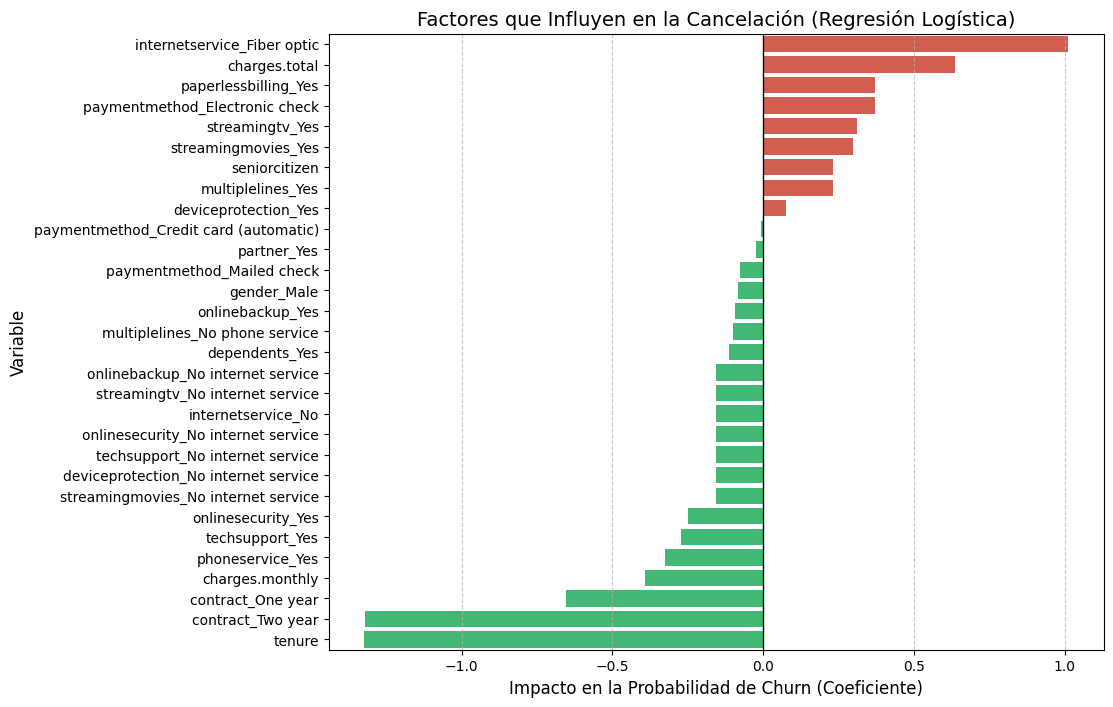

In [ ]:
#Preparar los datos de los coeficientes
coef_plot = coef_df.copy()
coef_plot = coef_plot.sort_values(by='Coeficiente', ascending=False)

# 2. Crear el gráfico
plt.figure(figsize=(10, 8))
colors = ['#e74c3c' if x > 0 else '#2ecc71' for x in coef_plot['Coeficiente']] # Rojo para riesgo, Verde para lealtad

sns.barplot(x='Coeficiente', y='Variable', data=coef_plot, palette=colors)

# 3. Estética del gráfico
plt.title('Factores que Influyen en la Cancelación (Regresión Logística)', fontsize=14)
plt.xlabel('Impacto en la Probabilidad de Churn (Coeficiente)', fontsize=12)
plt.ylabel('Variable', fontsize=12)
plt.axvline(x=0, color='black', linestyle='-', linewidth=1) # Línea en el cero para separar
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

1. Regresión Logística: Interpretación de Coeficientes ($\beta$) :

Variables que Impulsan el Churn (Coeficientes Positivos):
- InternetService_Fiber óptica (1.0124): riesgo más fuerte. Sugiere que, a pesar de ser una tecnología avanzada, los clientes de fibra tienen una altísima rotación, posiblemente por expectativas de precio o estabilidad no cumplidas.

- Charges.total (0.6359): Indica que a medida que el gasto acumulado sube, aumenta la probabilidad de fuga.  Aunque el gasto total suele asociarse a la permanencia, el modelo detecta que cargos acumulados elevados actúan como un disparador de fuga, posiblemente debido a la falta de incentivos por lealtad.

- Paperlessbilling_Yes(0,3700): Existe una correlación positiva entre la factura digital y la cancelación, lo cual suele asociarse a perfiles de clientes más jóvenes o tecnológicos que tienen menos barreras para cambiar de proveedor.

Variables que Evitan el Churn (Coeficientes Negativos):

- Tenure (-1,3243): Es el factor de retención más poderoso. Cada mes de antigüedad reduce significativamente la probabilidad de que el cliente se vaya.
- Contract_Two año (-1,3213) y Un año (-0,6532): Los contratos a largo plazo actúan como "anclas" de lealtad. El hecho de que el contrato de dos años sea el doble de fuerte que el de uno confirma que la estabilidad contractual es crítica para la retención.

2. Ramdom forest: Importancia de Variables (Importancia de Gini)

Jerarquía de Decisión:

Variables Numéricas Dominantes: son las más importantes para el modelo. Esto significa que el Random Forest prioriza el comportamiento histórico (cuánto ha pagado y cuánto tiempo ha estado) por encima de las características del servicio (charges.total y tenure)

Variables Categóricas Clave: El modelo detecta que el compromiso contractual es una señal muy clara para separar a los clientes que se quedan de los que se van.(charges monthly y contract_Two year)

Servicio Técnico: Variables como onlinesecurity_Yes y techsupport_Yes también aparecen con importancia relevante, lo que sugiere que los servicios de valor agregado ayudan al modelo a identificar perfiles de clientes más estables.


# CONCLUSIÓN

## Resumen del Rendimiento de los Modelos

Para identificar los factores de cancelación, evaluamos dos algoritmos principales con los siguientes resultados:

In [ ]:
import plotly.graph_objects as go

# datos basados en los resultados de los modelos de ML
data = {
    'Variable': [
        'Antigüedad (Tenure)',
        'Contrato 2 Años',
        'Fibra Óptica',
        'Contrato 1 Año',
        'Cargos Totales',
        'Factura Electrónica'
    ],
    'Impacto (Reg. Logística)': [
        'Protector (Lealtad)',
        'Protector (Lealtad)',
        'Riesgo (Impulsa Churn)',
        'Protector (Lealtad)',
        'Riesgo (Impulsa Churn)',
        'Riesgo (Impulsa Churn)'
    ],
    'Coeficiente (Beta)': [-1.3243, -1.3213, 1.0124, -0.6532, 0.6359, 0.3700],
    'Importancia (Random Forest)': ['Muy Alta', 'Alta', 'Media', 'Media', 'Crítica', 'Baja']
}

# tabla con Plotly
fig = go.Figure(data=[go.Table(
    header=dict(
        values=list(data.keys()),
        fill_color='paleturquoise',
        align='left',
        font=dict(size=12, color='black')
    ),
    cells=dict(
        values=[data[k] for k in data.keys()],
        fill_color='lavender',
        align='left',
        font=dict(size=11),
        height=30
    )
)])

# diseño
fig.update_layout(
    title='Comparativa de Variables Críticas: Regresión Logística vs Random Forest',
    width=900,
    height=450
)

fig.show()

Modelo Ganador: Se seleccionó la Regresión Logística como el modelo principal para la toma de decisiones, ya que su alto Recall permite capturar a la gran mayoría de clientes en riesgo, lo cual es prioritario para evitar la pérdida de ingresos.

## Identificación de Factores Críticos


Basándonos en los coeficientes y la importancia de variables, estos son los tres pilares que definen si un cliente se queda o se va:

A. Factores de Riesgo (Impulsan la Cancelación)
Tecnología de Fibra Óptica: Es el predictor de fuga más fuerte (Coef: 1.01). A pesar de ser un servicio premium, presenta una inestabilidad en la lealtad que sugiere insatisfacción con el precio o el soporte técnico.

Cargos Totales Acumulados: A medida que aumenta el gasto histórico, el riesgo de cancelación sube (Coef: 0.63). Esto indica un fenómeno de "fatiga del cliente" donde los usuarios antiguos no perciben beneficios por su permanencia.

Contratos de Corto Plazo (Mes a Mes): La ausencia de contratos anuales deja al cliente sin barreras de salida, facilitando la fuga inmediata ante cualquier oferta de la competencia.

B. Factores de Retención (Anclas de Lealtad)
Antigüedad (Tenure): El factor protector más potente (-1.32). Los clientes que superan los primeros meses de servicio tienden a estabilizarse.

Contratos de Largo Plazo: Los contratos de dos años reducen el riesgo de fuga drásticamente (-1.32), seguidos por los de un año (-0.65).

## Estrategias de Retención

Estrategia 1: Plan de "Lealtad por Gasto Acumulado"

- Problema: El aumento de charges.total impulsa la fuga.

- Acción: Implementar un programa de recompensas o descuentos automáticos cuando el cliente alcanza cierto rango de facturación histórica para revertir la percepción de "castigo por antigüedad".

Estrategia 2: Optimización del Servicio de Fibra Óptica

- Problema: La fibra óptica es el principal foco de alertas rojas.

- Acción: Realizar auditorías de satisfacción técnica exclusivas para este segmento y ofrecer planes de soporte "VIP" gratuitos durante los primeros 6 meses para asegurar que el cliente valore la calidad del servicio antes de considerar una migración.

Estrategia 3: Incentivo a la Estabilidad Contractual

- Problema: Los clientes "Mes a Mes" no tienen protección contra el churn.

- Acción: Lanzar campañas de migración de contratos mensuales a anuales ofreciendo un mes gratuito o servicios adicionales (como OnlineSecurity o TechSupport) sin costo, ya que estos servicios también mostraron ser relevantes para la retención en el Random Forest.

# CONCLUSIÓN

El análisis demuestra que la cancelación no es un evento aleatorio, sino una respuesta a la falta de incentivos de largo plazo y posibles deficiencias en el servicio de fibra. Al enfocar los esfuerzos en la conversión de contratos y en el reconocimiento del gasto acumulado, la empresa puede reducir el churn de manera significativa utilizando la Regresión Logística como sistema de alerta temprana.